# Plane-parallel slab example showing the usage of:
# High-level `LineRt` with callable fields

This notebook mirrors `docs/examples/plane_parallel_hl.py`
but in interactive form.  A uniform slab of CO (J=1->0) is
illuminated from one face; photons scatter in the line and
are continuously absorbed by dust.  The field arrays
(`n_species`, `temperature`, `vel`) are provided as
**callables** so they can be spatially varying.

Run directory is auto-created under `/tmp/line_rt/`.

In [1]:
############################################################
# Import things

import sys, os;
_PROJECT = os.path.expanduser( \
    '~/Seafile/seafile_sync/code/line_rt_pipeline' );
if _PROJECT not in sys.path:
    sys.path.insert( 0, _PROJECT );

%matplotlib inline
import matplotlib;
import matplotlib.pyplot as plt;
from numpy import full, zeros, linspace, asarray, sqrt, \
                  max as np_max, float64;

from core.line_rt              import LineRt;
from molecular.transition_info import TransitionInfo;

AU   = 1.49598e13;   # cm
Lsun = 3.828e33;     # erg/s
############################################################

In [2]:
############################################################
# Physical parameters and callable fields
##############################

tau0_slab   = 1e1;
b_sca       = 1.0e5;
temperature = 2.0;

ti         = TransitionInfo( 'CO', 0 );  # CO J=1->0 (idx 0)
tr         = ti.transition;
sigma_co   = ti.species_data.cross_section( 0, b_sca );
L_slab_cm  = 10.0 * AU;   # x_min=-5, x_max=5 -> L=10 AU
n_species  = ( tau0_slab / L_slab_cm ) / sigma_co; # cm^-3

def n_total_callable( X, Y, Z ):
    res = full( X.shape, n_species, dtype = float64 );
    res[ X > 0 ] *= 2;
    return res;

def temperature_callable( X, Y, Z ):
    return full( X.shape, temperature, dtype = float64 );

def vx_callable( X, Y, Z ):
    return zeros( X.shape, dtype = float64 );

print( 'CO J=%s->%s, n_species=%.2e cm^-3' \
       % ( tr.upper, tr.lower, n_species ) );
############################################################

CO J=1->0, n_species=7.84e+01 cm^-3


In [3]:
############################################################
# Configure LineRt (Group 1: species-based)
##############################
# Pass the callables directly as n_species, temperature,
# and vel.  LineRt calls them internally after building
# the mesh.

rt = LineRt(
    n_cell       = ( 64, 2, 2 ),
    x_min        = ( -5, 0, 0 ), x_max = ( 5, 0.2, 0.2 ),
    unit_l0      = AU, unit_t0 = 1.0,

    transition_info = ti,
    n_species       = n_total_callable,
    temperature     = temperature_callable,
    b_sca           = b_sca,
    vel             = ( vx_callable, 0.0, 0.0 ),

    ph_mode      = 2,  # R_IIA, const-mem (production mode)
    n_step       = 200000,
    n_scat       = 20000,
    n_cycles     = 3,
    n_emission_max = 5,
    visualize    = False,
);
rt.set_boundary( 'fre fre per per per per' );

# Slab source at x=-5 (left face).
# With transition_info set, a bare flux is interpreted as
# energetic flux at the auto-lambda line centre.
h_cgs = 6.62607015e-27; # Planck constant [erg s]
c_cgs = 2.99792458e10;  # speed of light [cm/s]
F0_cgs = 1e6;           # photon number flux [cm^-2 s^-1]
E_ph   = h_cgs * c_cgs / ( tr.wavelength_um * 1e-4 );

rt.add_source\
( type     = 'slab', x = -5.0, direction = '+x',
  n_photon = 20000,
  flux     = F0_cgs * E_ph, # energy flux [erg cm^-2 s^-1]
  sigma    = b_sca / sqrt( 2 ),
);

print( 'Mesh: %s, sources: %d' \
       % ( rt._n_cell, len( rt._sources ) ) );
############################################################

Mesh: (64, 2, 2), sources: 1


In [4]:
############################################################
# Run the Monte Carlo simulations iteratively
##############################
# The run directory is printed and everything (`.par`,
# `.bin` files) goes under `/tmp/line_rt/rt_<timestamp>/`.

results = rt.run(  );

############################################################

=== Consistency check ===
  species  : CO (10 levels, 9 transitions)
  n_species: <callable n_total_callable> cm⁻³
  temperature: <function temperature_callable at 0x7c58704401a0> K
  Transition #0: J=1->0, E_u=3.8 K, E_l=0.0 K, g_u=3, g_l=1, A_ul=7.20e-08 s⁻¹, ν=115.271 GHz, λ=2600.8 µm
  σ₀ = (b_sca to be resolved from callable at runtime)
  b_sca    : 100000.0 cm/s
  mfp_i_sca_0: (not provided)
  ── Using Group 1 (species-based) ──
  sources  : 1 source(s)
    [0] slab, 20000 photons, 7.6379373226065e-10 erg cm⁻² s⁻¹ (λ=0.260076218649964 cm)
=== All checks passed ===

[LineRt] Run directory: /tmp/line_rt/rt_20260802_141232
[iterate] Run directory: /tmp/line_rt/rt_20260802_141232
Wrote fields (fixed): /tmp/line_rt/rt_20260802_141232/fields_fixed.bin
Wrote fields (line): /tmp/line_rt/rt_20260802_141232/fields_cycle0.bin
Wrote photons: /tmp/line_rt/rt_20260802_141232/photons_cycle0.bin (20000 photons, 9 cols)
Wrote par file: /tmp/line_rt/rt_20260802_141232/cycle0.par


[cycle 0] Done in 1s, bin=cycle0_00000.bin
Wrote fields (line): /tmp/line_rt/rt_20260802_141232/fields_cycle1.bin
Wrote photons: /tmp/line_rt/rt_20260802_141232/photons_cycle1.bin (21280 photons, 9 cols)
Wrote par file: /tmp/line_rt/rt_20260802_141232/cycle1.par


[cycle 1] Done in 1s, bin=cycle1_00000.bin
Wrote fields (line): /tmp/line_rt/rt_20260802_141232/fields_cycle2.bin
Wrote photons: /tmp/line_rt/rt_20260802_141232/photons_cycle2.bin (22560 photons, 9 cols)
Wrote par file: /tmp/line_rt/rt_20260802_141232/cycle2.par


[cycle 2] Done in 0s, bin=cycle2_00000.bin


In [5]:
############################################################
# Print the run information
##############################

res_list = results[ 'results' ];
mesh     = results[ 'mesh' ];
nxc      = int( mesh[ 'n_cell' ][ 0 ] );
x_cell   = linspace( -5, 5, nxc );

for k, res in enumerate( res_list ):
    flx   = res.get( 'flx' );
    exc   = res.get( 'exc_flux_flat', res.get( 'excitation_flux' ) );
    n_esc = len( res.get( 'photons', {} ).get( 'vel', [] ) );
    if flx is not None:
        print( '  Cycle %d: flx_max=%.2e  exc_max=%.2e  n_esc=%d' \
               % ( k, np_max( flx ), np_max( exc ), n_esc ) );
    else:
        print( '  Cycle %d: flx=N/A  exc=N/A  n_esc=%d' \
               % ( k, n_esc ) );
############################################################

  Cycle 0: flx_max=3.39e+06  exc_max=1.48e+06  n_esc=20000
  Cycle 1: flx_max=3.39e+06  exc_max=1.48e+06  n_esc=21280
  Cycle 2: flx_max=3.38e+06  exc_max=1.48e+06  n_esc=22560


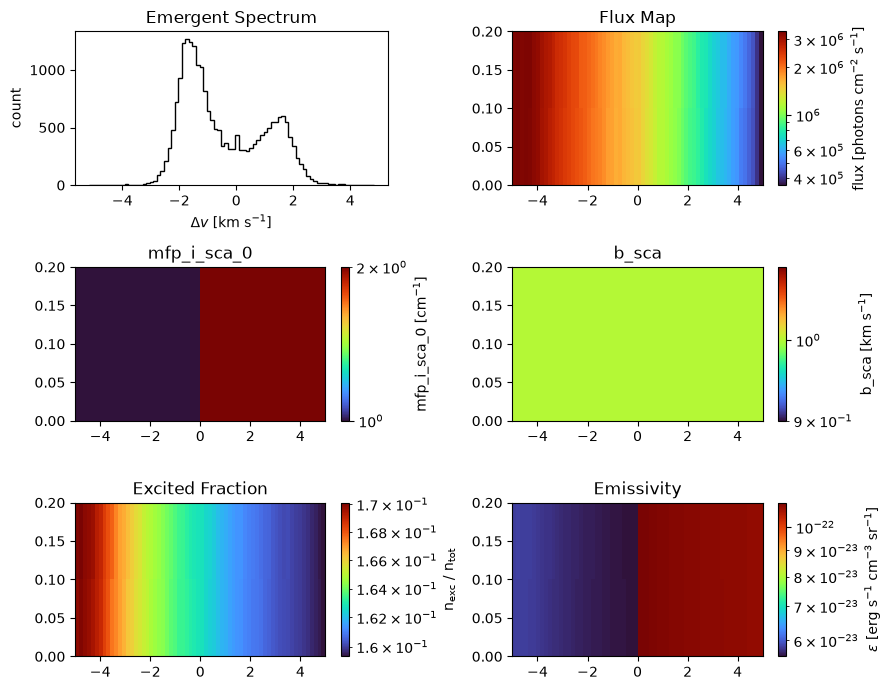

In [15]:
############################################################
# Default multi-panel plot
##############################
# `default_plot(  )` from `core.visualize` generates a
# 2-column, N-row panel grid.  The default field list:
# emergent spectrum (km/s histogram), flux map, mfp_i_sca_0,
# b_sca, excited fraction, emissivity - all as logarithmic
# colormaps (except the spectrum).  Missing fields leave a
# blank panel with title.  Pass `dyn_range=True` to clip the
# color scale to integer-dex bounds.
##############################

from core.visualize import default_plot;

fig, axes = default_plot( results, figsize = ( 9, 7 ) );
############################################################

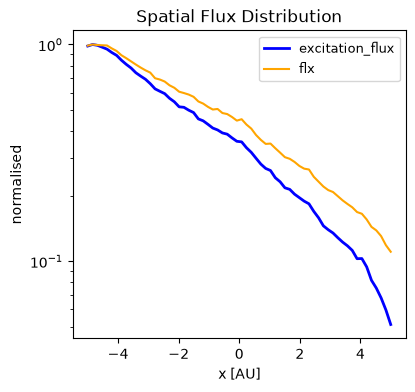

In [10]:
############################################################
# Spatial distribution
##############################

exc_flat = results.get( 'exc_flux_flat' );
flx_flat = results.get( 'flx' );

fig, ax = plt.subplots( figsize = ( 4.3, 4 ) );
if exc_flat is not None and flx_flat is not None:
    # 3D arrays (nz, ny, nx) -> take the x-profile at z=y=0
    exc_x = exc_flat[ 0, 0, : ];
    flx_x = flx_flat[ 0, 0, : ];
    ax.plot( x_cell, exc_x / ( exc_x.max(  ) or 1 ), 'b-',
             lw = 2, label = 'excitation_flux' );
    ax.plot( x_cell, flx_x / ( flx_x.max(  ) or 1 ),
             color = 'orange',  lw = 1.5, label = 'flx' );
    ax.set( xlabel = 'x [AU]', ylabel = 'normalised' );
    ax.set_yscale( 'log' );
    ax.legend( fontsize = 9 );
else:
    ax.text( 0.5, 0.5, 'No flux data',
             transform = ax.transAxes, ha = 'center' );
ax.set_title( 'Spatial Flux Distribution' );
plt.show(  );
############################################################

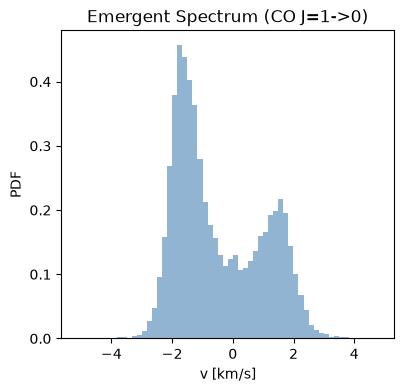

In [11]:
############################################################
# Emergent spectra
##############################

spectrum = results.get( 'spectrum', {} );
vel_data = asarray( spectrum.get( 'vel', [ ] ) );

fig, ax = plt.subplots( figsize = ( 4.3, 4 ) );
if len( vel_data ) > 0:
    ax.hist( vel_data * 1e-5, bins = 60, density = True, \
             alpha = 0.6, color = 'steelblue' );
    ax.set( xlabel = 'v [km/s]', ylabel = 'PDF' );
else:
    ax.text( 0.5, 0.5, 'No escaped photons', \
             transform = ax.transAxes, ha = 'center' );
ax.set_title( 'Emergent Spectrum (CO J=1->0)' );
plt.show(  );
############################################################

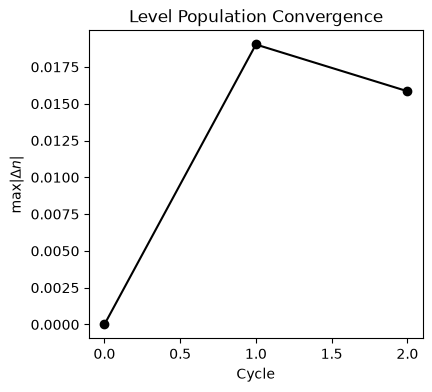

In [12]:
############################################################
# Population convergence
##############################

pop_hist = [ r[ 'populations' ] for r in res_list \
             if 'populations' in r ];

fig, ax = plt.subplots( figsize = ( 4.3, 4 ) );
if len( pop_hist ) >= 2:
    from core.visualize import plot_convergence;
    plot_convergence( ax, pop_hist,
                      list( range( len( pop_hist ) ) ) );
else:
    ax.text( 0.5, 0.5, 'No convergence data', \
             transform = ax.transAxes, ha = 'center' );
ax.set_title( 'Level Population Convergence' );
plt.show(  );
############################################################

In [13]:
############################################################
# Run directory structure
##############################

run_dir = results.get( 'run_dir' ) or rt._resolve_path(  );
print( 'Run directory: %s' % run_dir );
for f in sorted( os.listdir( run_dir ) ):
    sz = os.path.getsize( os.path.join( run_dir, f ) );
    print( '  %-30s  %10d bytes' % ( f, sz ) );
############################################################

Run directory: /tmp/line_rt/rt_20260802_141232
  cycle0.par                             832 bytes
  cycle0_00000.bin                    677698 bytes
  cycle1.par                             832 bytes
  cycle1_00000.bin                    718658 bytes
  cycle2.par                             832 bytes
  cycle2_00000.bin                    759618 bytes
  fields_cycle0.bin                     5181 bytes
  fields_cycle1.bin                     5181 bytes
  fields_cycle2.bin                     5181 bytes
  fields_fixed.bin                     10225 bytes
  photons_cycle0.bin                  720133 bytes
  photons_cycle1.bin                  766213 bytes
  photons_cycle2.bin                  812293 bytes
